# 2. NumPy, engineering units, and plots

        Array operations replace repetitive loops. Unit conversion is part of the calculation,
        not an afterthought.

In [1]:
from pathlib import Path
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ROOT = Path.cwd().resolve()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT / "src"))


In [2]:
from petroleum_python.units import kelvin_to_celsius, md_to_m2, psi_to_mpa
pressure_psi = np.arange(1000, 3001, 250)
pressure_mpa = psi_to_mpa(pressure_psi)
temperature_k = np.array([323.15, 343.15, 363.15])
print(pd.DataFrame({"pressure_psi": pressure_psi, "pressure_mpa": pressure_mpa}).head())
print("Temperatures (°C):", kelvin_to_celsius(temperature_k))
print("100 mD in m²:", md_to_m2(100))


   pressure_psi  pressure_mpa
0          1000      6.894757
1          1250      8.618447
2          1500     10.342136
3          1750     12.065825
4          2000     13.789515
Temperatures (°C): [50. 70. 90.]
100 mD in m²: 9.869233e-14


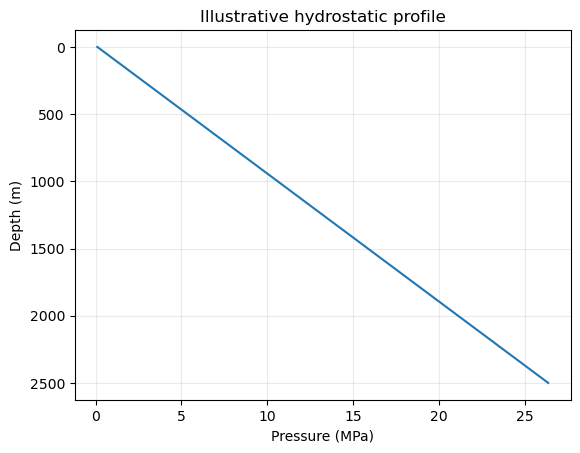

In [3]:
depth_m = np.linspace(0, 2500, 60)
pressure_gradient_mpa_m = 0.0105
hydrostatic_pressure_mpa = 0.1 + pressure_gradient_mpa_m * depth_m
plt.plot(hydrostatic_pressure_mpa, depth_m)
plt.gca().invert_yaxis()
plt.xlabel("Pressure (MPa)")
plt.ylabel("Depth (m)")
plt.title("Illustrative hydrostatic profile")
plt.grid(alpha=0.25)
plt.show()


## Challenge

        Create a vector of permeability values from 1 to 1000 mD on a logarithmic scale, convert
        it to square metres, and plot both representations.